In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/loan_default_clean.csv")
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (255347, 17)

Columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [3]:
default_counts = df["Default"].value_counts()

print(default_counts)

print("\nPercentage:")
print(df["Default"].value_counts(normalize=True) * 100)

Default
0    225694
1     29653
Name: count, dtype: int64

Percentage:
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


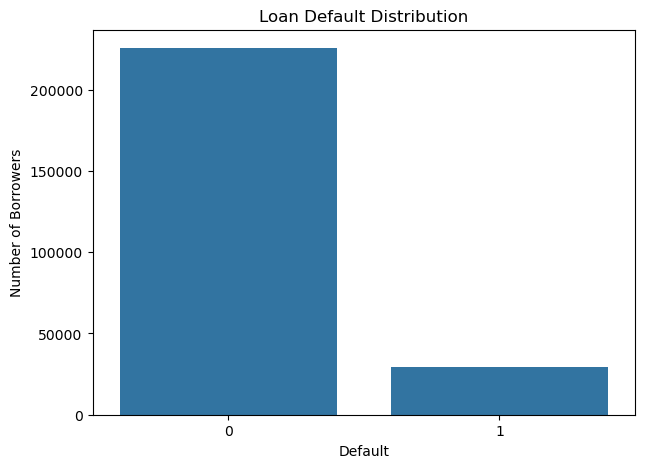

In [4]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Default")

plt.title("Loan Default Distribution")
plt.xlabel("Default")
plt.ylabel("Number of Borrowers")

plt.show()

In [5]:
numeric_features = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio"
]

df[numeric_features].describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000


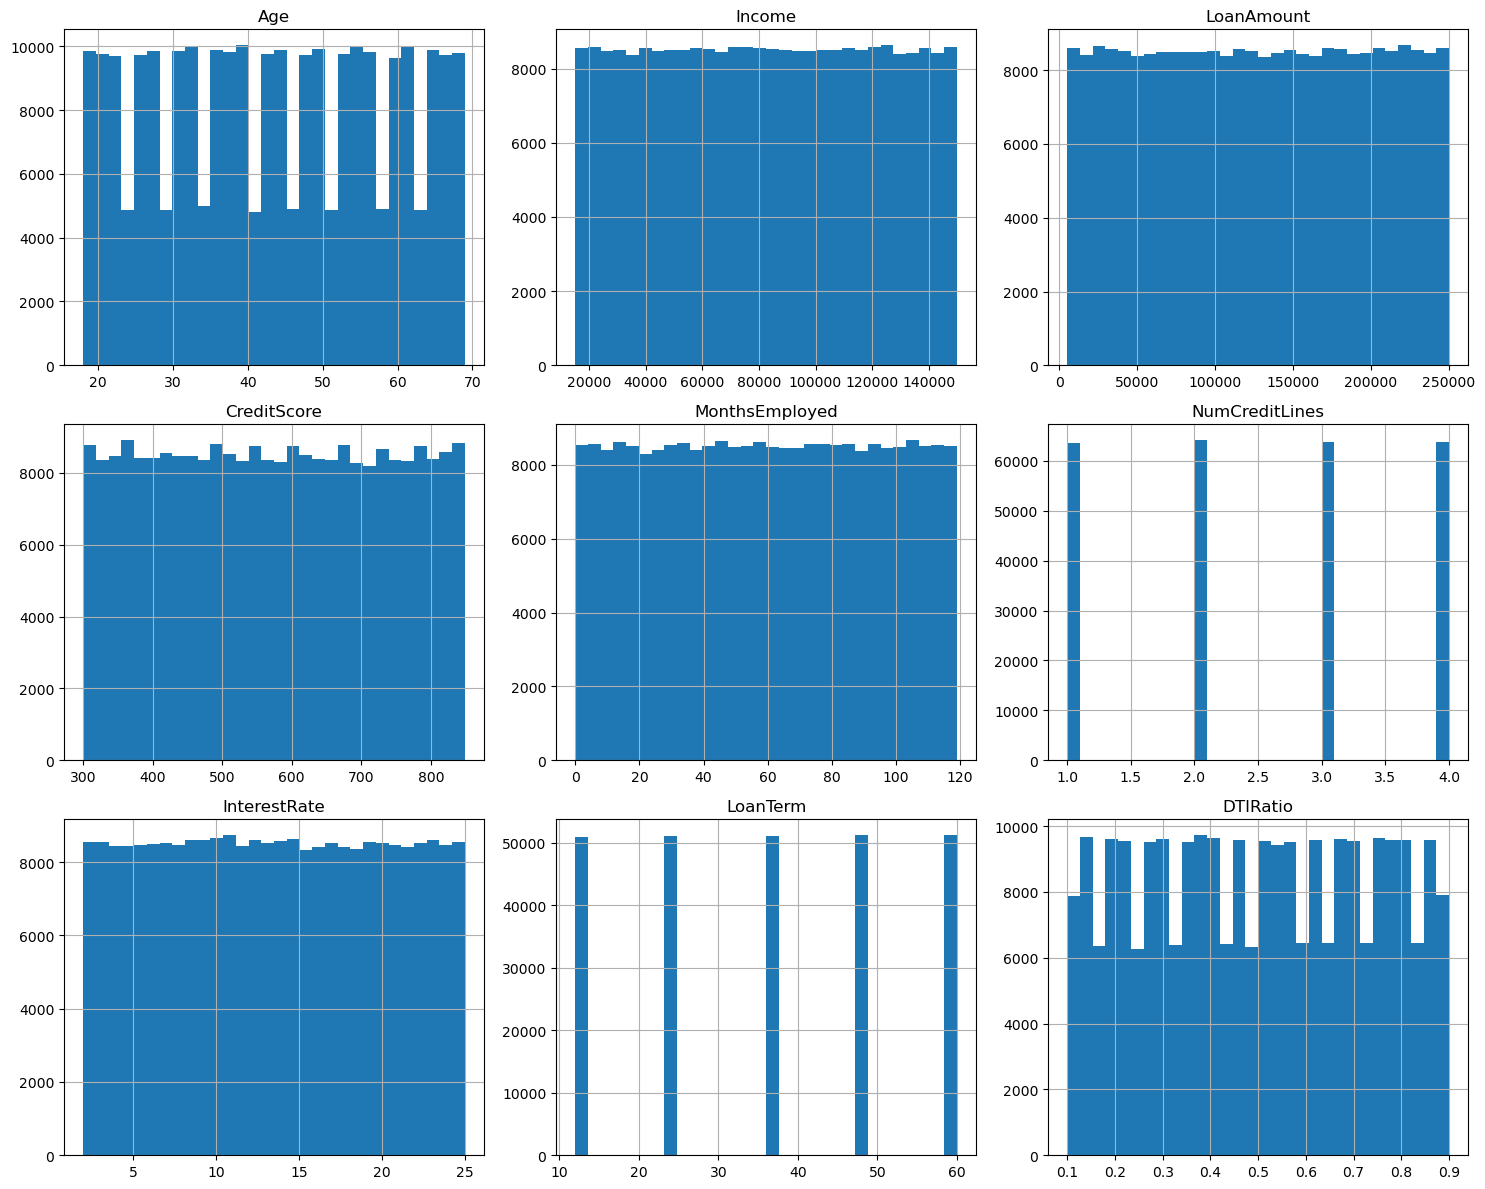

In [6]:
df[numeric_features].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

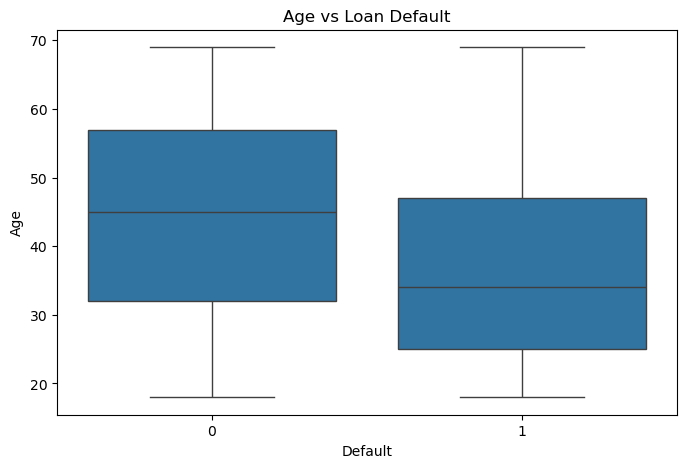

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Default",
    y="Age"
)

plt.title("Age vs Loan Default")
plt.xlabel("Default")
plt.ylabel("Age")

plt.show()

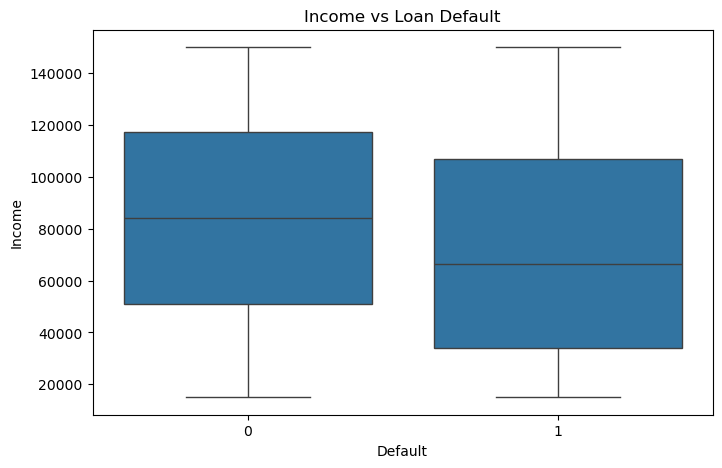

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Default",
    y="Income"
)

plt.title("Income vs Loan Default")
plt.xlabel("Default")
plt.ylabel("Income")

plt.show()

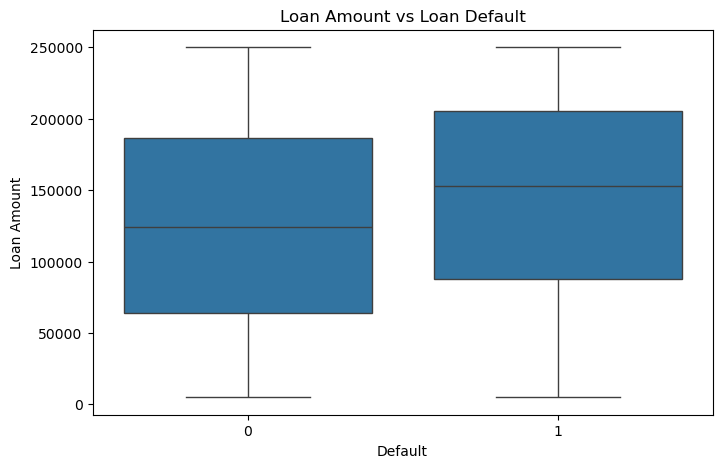

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Default",
    y="LoanAmount"
)

plt.title("Loan Amount vs Loan Default")
plt.xlabel("Default")
plt.ylabel("Loan Amount")

plt.show()

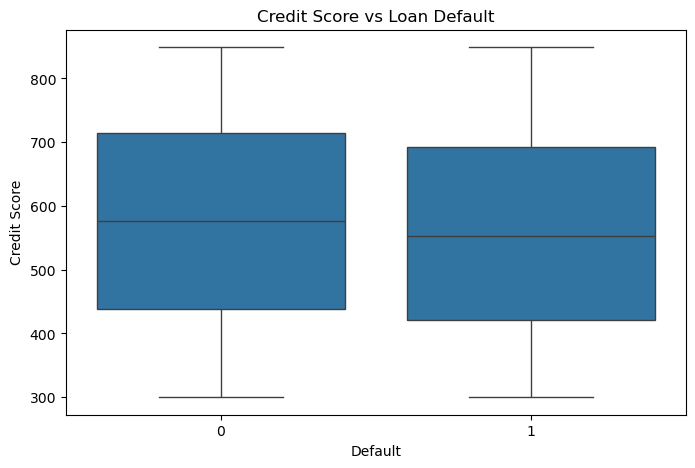

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Default",
    y="CreditScore"
)

plt.title("Credit Score vs Loan Default")
plt.xlabel("Default")
plt.ylabel("Credit Score")

plt.show()

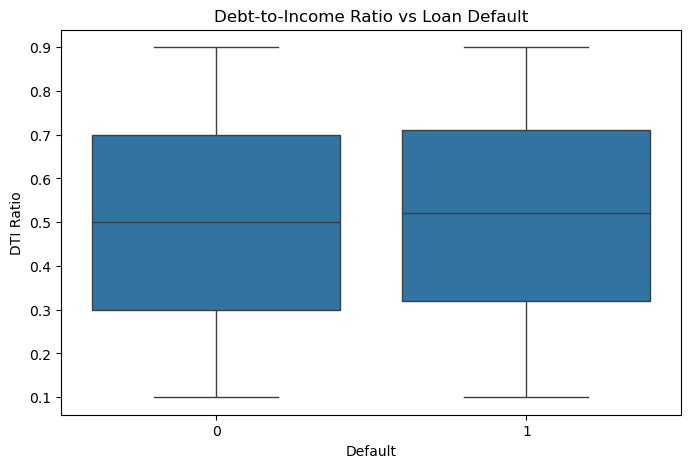

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Default",
    y="DTIRatio"
)

plt.title("Debt-to-Income Ratio vs Loan Default")
plt.xlabel("Default")
plt.ylabel("DTI Ratio")

plt.show()

In [12]:
education_default = (
    df.groupby("Education")["Default"]
      .mean()
      .sort_values(ascending=False)
)

print(education_default)

Education
High School    0.128789
Bachelor's     0.121011
Master's       0.108717
PhD            0.105860
Name: Default, dtype: float64


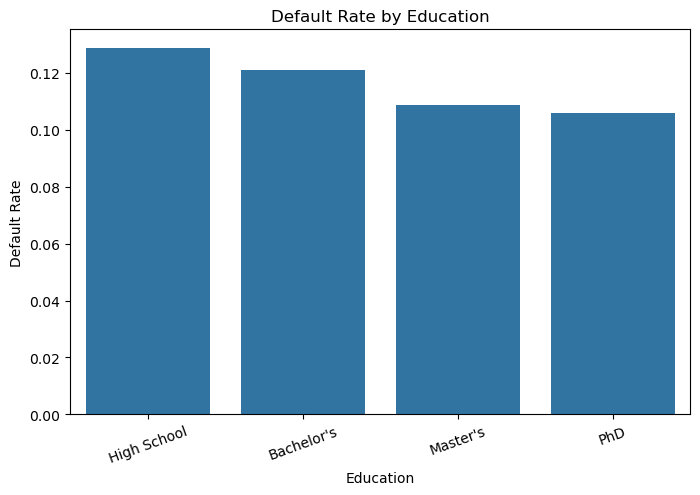

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=education_default.index,
    y=education_default.values
)

plt.title("Default Rate by Education")
plt.xlabel("Education")
plt.ylabel("Default Rate")

plt.xticks(rotation=20)

plt.show()

In [14]:
employment_default = (
    df.groupby("EmploymentType")["Default"]
      .mean()
      .sort_values(ascending=False)
)

print(employment_default)

EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64


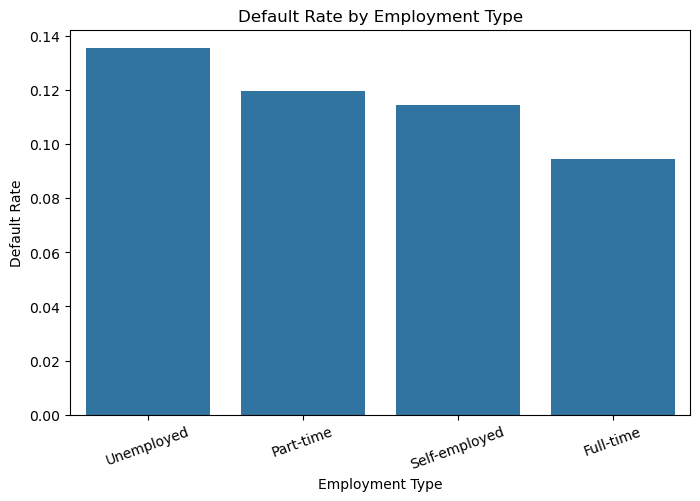

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=employment_default.index,
    y=employment_default.values
)

plt.title("Default Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Default Rate")

plt.xticks(rotation=20)

plt.show()

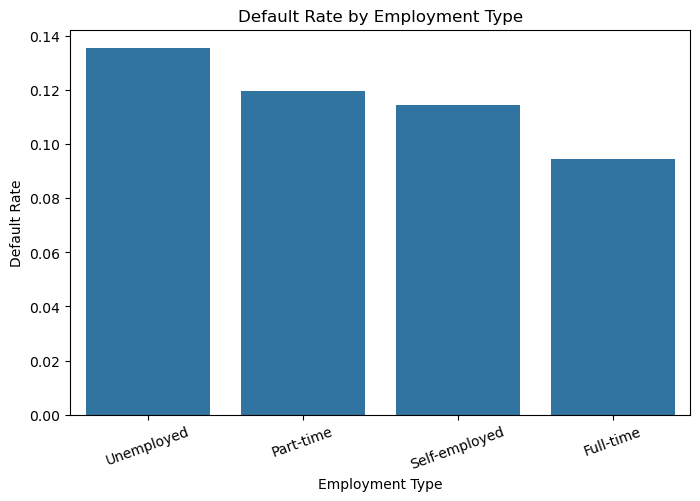

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=employment_default.index,
    y=employment_default.values
)

plt.title("Default Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Default Rate")

plt.xticks(rotation=20)

plt.show()

In [17]:
marital_default = (
    df.groupby("MaritalStatus")["Default"]
      .mean()
      .sort_values(ascending=False)
)

print(marital_default)

MaritalStatus
Divorced    0.125328
Single      0.119124
Married     0.103972
Name: Default, dtype: float64


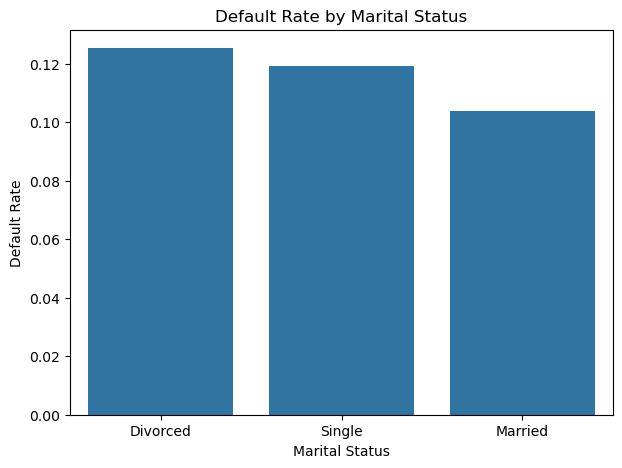

In [18]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=marital_default.index,
    y=marital_default.values
)

plt.title("Default Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Default Rate")

plt.show()

In [19]:
loan_purpose_default = (
    df.groupby("LoanPurpose")["Default"]
      .mean()
      .sort_values(ascending=False)
)

print(loan_purpose_default)

LoanPurpose
Business     0.123260
Auto         0.118814
Education    0.118381
Other        0.117885
Home         0.102348
Name: Default, dtype: float64


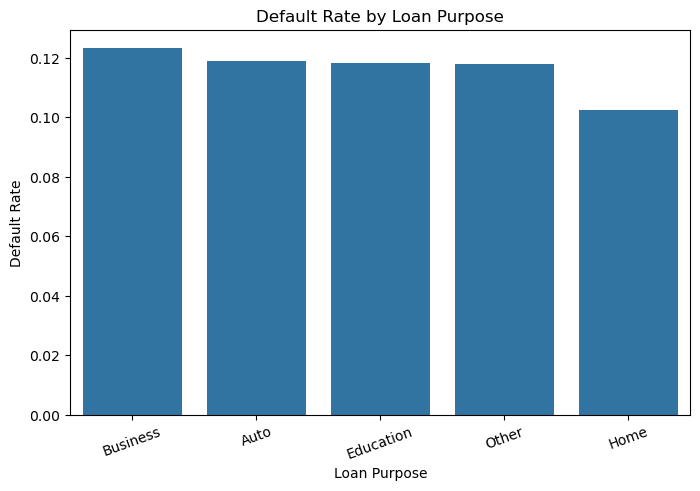

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=loan_purpose_default.index,
    y=loan_purpose_default.values
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate")

plt.xticks(rotation=20)

plt.show()

In [21]:
binary_features = [
    "HasMortgage",
    "HasDependents",
    "HasCoSigner"
]

for feature in binary_features:
    default_rate = df.groupby(feature)["Default"].mean()

    print(f"\n{feature}")
    print(default_rate)


HasMortgage
HasMortgage
No     0.123451
Yes    0.108806
Name: Default, dtype: float64

HasDependents
HasDependents
No     0.127244
Yes    0.105024
Name: Default, dtype: float64

HasCoSigner
HasCoSigner
No     0.128661
Yes    0.103601
Name: Default, dtype: float64


In [22]:
correlation = df[numeric_features + ["Default"]].corr()

correlation

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


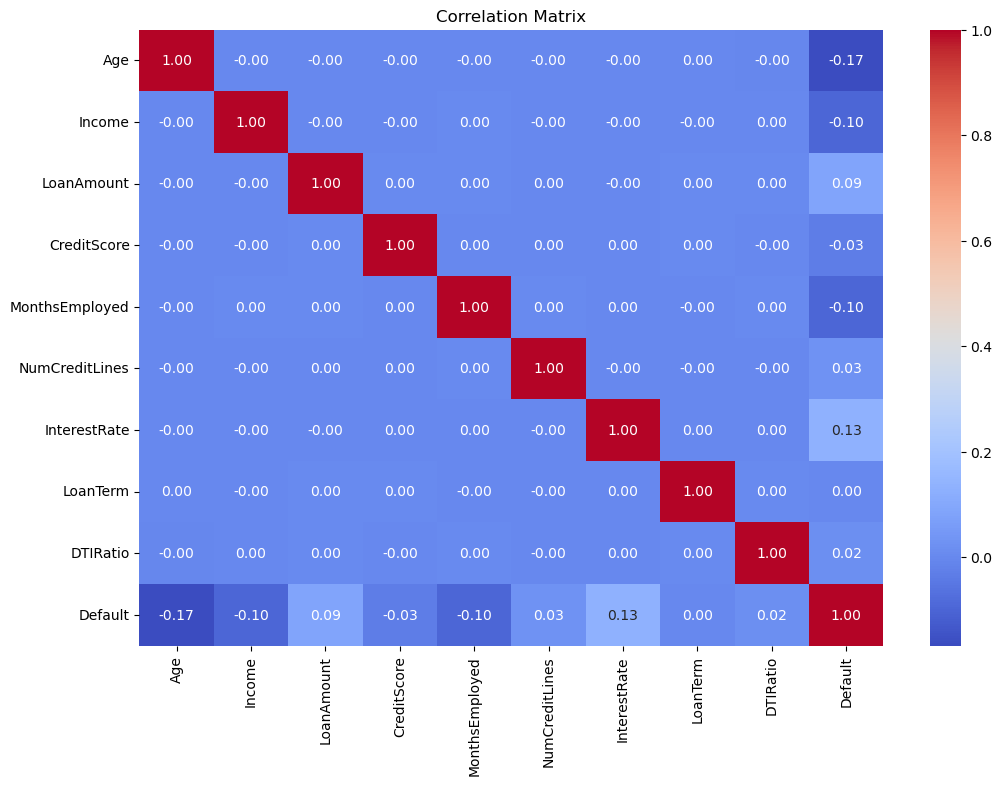

In [23]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()